In [ ]:
## 1. Cargar los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

print("Directorio actual:", ROOT)
print("Ruta de datos:", DATA_PATH)

Directorio actual: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test
Ruta de datos: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test\data_raw


In [3]:
df_demo       = pd.read_csv(DATA_PATH / "df_demo_clean.csv")
df_experiment = pd.read_csv(DATA_PATH / "df_experiment_clean.csv")
df_web        = pd.read_csv(DATA_PATH / "df_web_clean.csv")

print("Datos cargados correctamente!")
print("df_demo:      ", len(df_demo), "filas")
print("df_experiment:", len(df_experiment), "filas")
print("df_web:       ", len(df_web), "filas")

Datos cargados correctamente!
df_demo:       70594 filas
df_experiment: 50500 filas
df_web:        744641 filas


## 2. Análisis de clientes.
¿Quiénes son los clientes principales? ¿Son jóvenes o mayores?
-Empezamos analizando la distribución de edades:

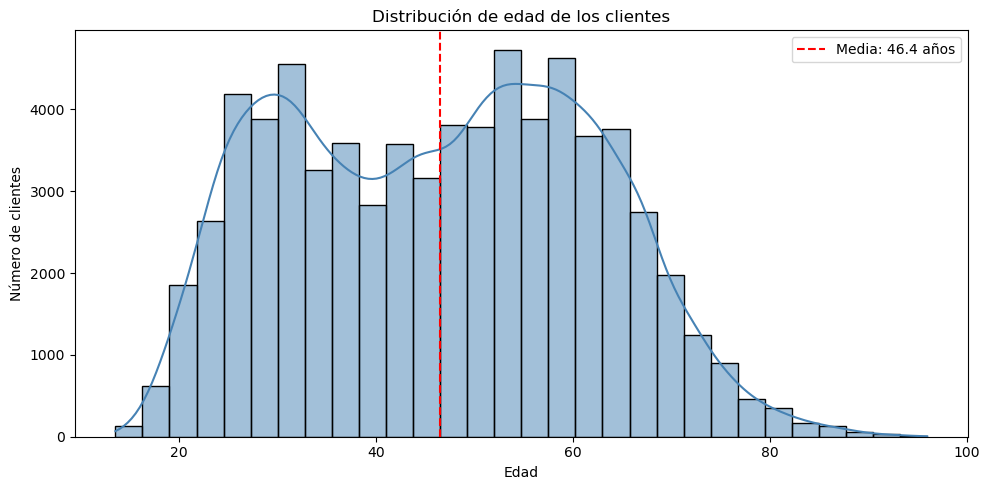

Edad media: 46.4
Edad mediana: 47.0
Edad mínima: 13.5
Edad máxima: 96.0


In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df_demo["clnt_age"], bins=30, kde=True, color="steelblue")
plt.title("Distribución de edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")
plt.axvline(df_demo["clnt_age"].mean(), color="red", linestyle="--", label=f'Media: {df_demo["clnt_age"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.show()

print("Edad media:", round(df_demo["clnt_age"].mean(), 1))
print("Edad mediana:", round(df_demo["clnt_age"].median(), 1))
print("Edad mínima:", df_demo["clnt_age"].min())
print("Edad máxima:", df_demo["clnt_age"].max())

Interpretación:
- La edad media es de 46.4 años y la mediana es de 47 años. Como son muy parecidas, indica que tratamos con adultos de mediana edad.
- El gráfico muestra dos grupos diferenciados: Gente joven entre los 25-30 años y gente adulta de 55-60 años. Esto puede decirnos que hay dos tipos de clientes muy distintos entre sí.
- Aunque hay dos grupos diferenciados, parece que la gente adulta supera a los jovenes en cantidad.

- Analizamos la antigüedad:

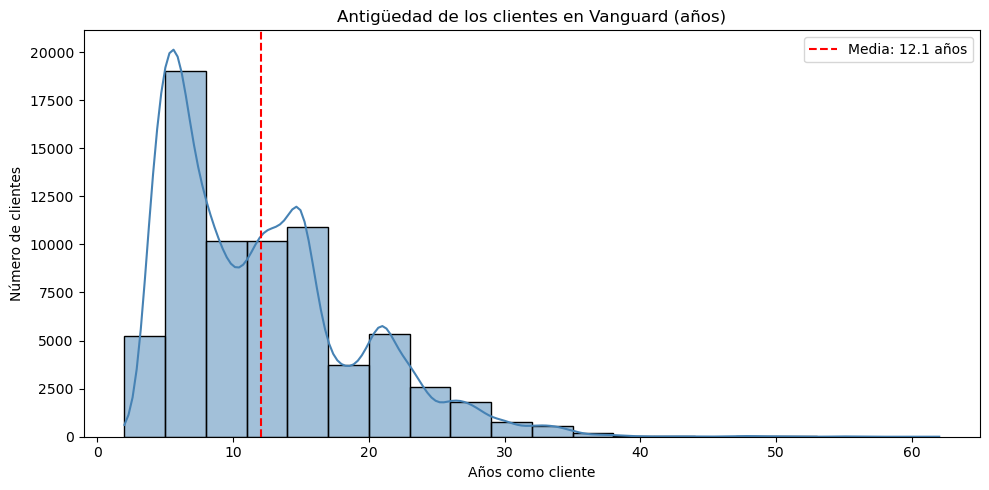

Antigüedad media: 12.1 años
Antigüedad mediana: 11.0 años
Mínimo: 2.0 años
Máximo: 62.0 años


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df_demo["clnt_tenure_yr"], bins=20, kde=True, color="steelblue")
plt.title("Antigüedad de los clientes en Vanguard (años)")
plt.xlabel("Años como cliente")
plt.ylabel("Número de clientes")
plt.axvline(df_demo["clnt_tenure_yr"].mean(), color="red", linestyle="--", label=f'Media: {df_demo["clnt_tenure_yr"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.show()

print("Antigüedad media:", round(df_demo["clnt_tenure_yr"].mean(), 1), "años")
print("Antigüedad mediana:", round(df_demo["clnt_tenure_yr"].median(), 1), "años")
print("Mínimo:", df_demo["clnt_tenure_yr"].min(), "años")
print("Máximo:", df_demo["clnt_tenure_yr"].max(), "años")

Conclusiones:
- La mayoría de clientes tienen entre 5-7 años aproximádamente de antigüedad
- La media es de 12.1 años, lo que indica que no son clientes nuevos.
- Hay muy pocos clientes que llegan a más de 30 años de antigüedad, lo que quiere decir es que Vanguard tiene una base de clientes fiel y establecida.

Analizamos distribución de género:

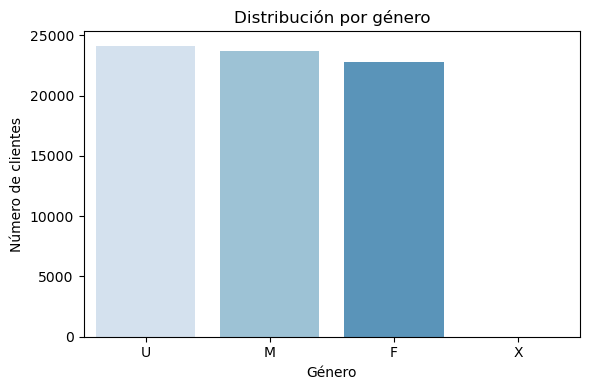

gendr
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64

gendr
U    34.2
M    33.6
F    32.2
X     0.0
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_demo, x="gendr", hue="gendr", legend=False, palette="Blues")
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

print(df_demo["gendr"].value_counts())
print()
print(df_demo["gendr"].value_counts(normalize=True).round(3) * 100)